<a href="https://colab.research.google.com/github/belokonr/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/lab10/lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr

start = "2010-01-01"
end = "2024-12-31"

series = {
    "CPIAUCSL": "cpi",
    "UNRATE": "unrate",
    "FEDFUNDS": "fedfunds",
    "INDPRO": "indpro",
    "RSAFS": "retail_sales",
    "DGS10": "dgs10",
    "PAYEMS": "payrolls",
    "M2SL": "m2"
}

df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1)
df = df.resample("MS").last()       # monthly frequency
df = df.dropna()                    # remove missing rows

print(df.head())
print(df.shape)

                cpi  unrate  fedfunds   indpro  retail_sales  dgs10  payrolls  \
DATE                                                                            
2010-01-01  217.488     9.8      0.11  89.3426      339093.0   3.63  129802.0   
2010-02-01  217.281     9.8      0.13  89.6779      339580.0   3.61  129706.0   
2010-03-01  217.353     9.9      0.16  90.2928      346974.0   3.84  129866.0   
2010-04-01  217.403     9.9      0.20  90.5991      349869.0   3.69  130120.0   
2010-05-01  217.290     9.6      0.20  91.8230      346858.0   3.31  130642.0   

                m2  
DATE                
2010-01-01  8477.7  
2010-02-01  8527.3  
2010-03-01  8523.5  
2010-04-01  8554.8  
2010-05-01  8609.0  
(180, 8)


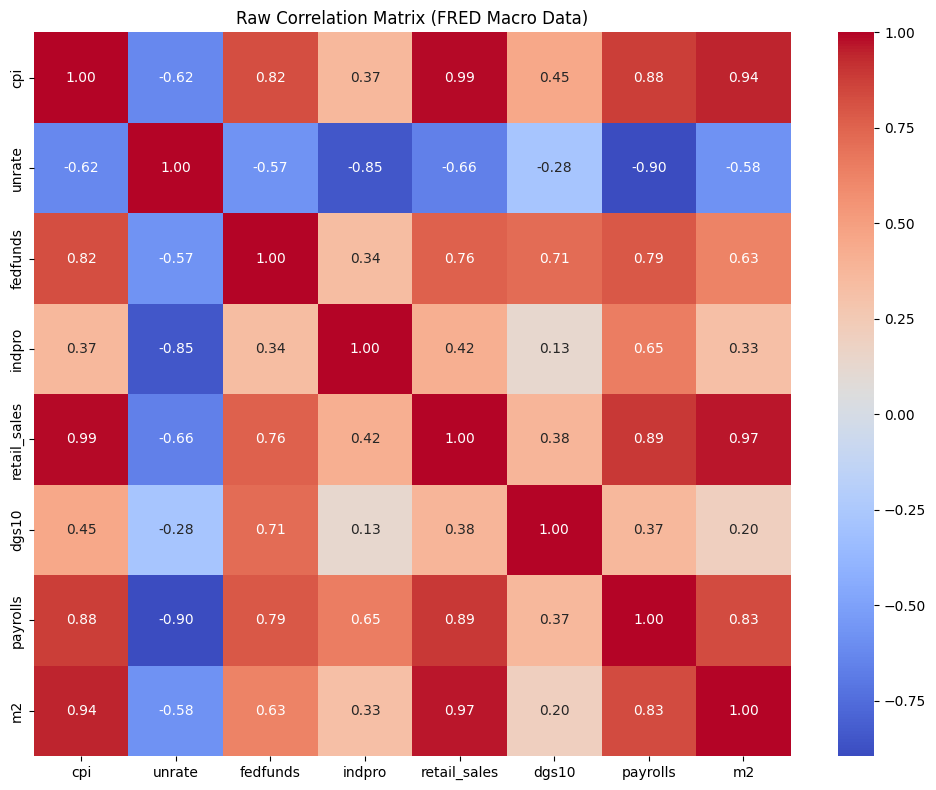

In [2]:
plt.figure(figsize=(10, 8))

corr = df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Raw Correlation Matrix (FRED Macro Data)")
plt.tight_layout()
plt.show()

In [4]:
y = df['cpi']

X = df[[
    "unrate", "fedfunds", "indpro",
    "retail_sales", "dgs10", "payrolls", "m2"
]]

X = sm.add_constant(X)   # add intercept

model = sm.OLS(y, X)

results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    cpi   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     2875.
Date:                Fri, 27 Feb 2026   Prob (F-statistic):          1.39e-174
Time:                        19:12:27   Log-Likelihood:                -428.27
No. Observations:                 180   AIC:                             872.5
Df Residuals:                     172   BIC:                             898.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.2423     35.522     -0.345   

In [7]:
X_vif = df[[
    "unrate", "fedfunds", "indpro",
     "dgs10", "m2"
]].copy()

X_vif = sm.add_constant(X_vif)   # add constant

vif_table = pd.DataFrame()
vif_table["feature"] = X_vif.columns
vif_table["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_table.sort_values("VIF", ascending=False))

    feature          VIF
0     const  4600.128877
1    unrate     6.289179
2  fedfunds     4.363013
3    indpro     4.323439
4     dgs10     2.588827
5        m2     2.450075


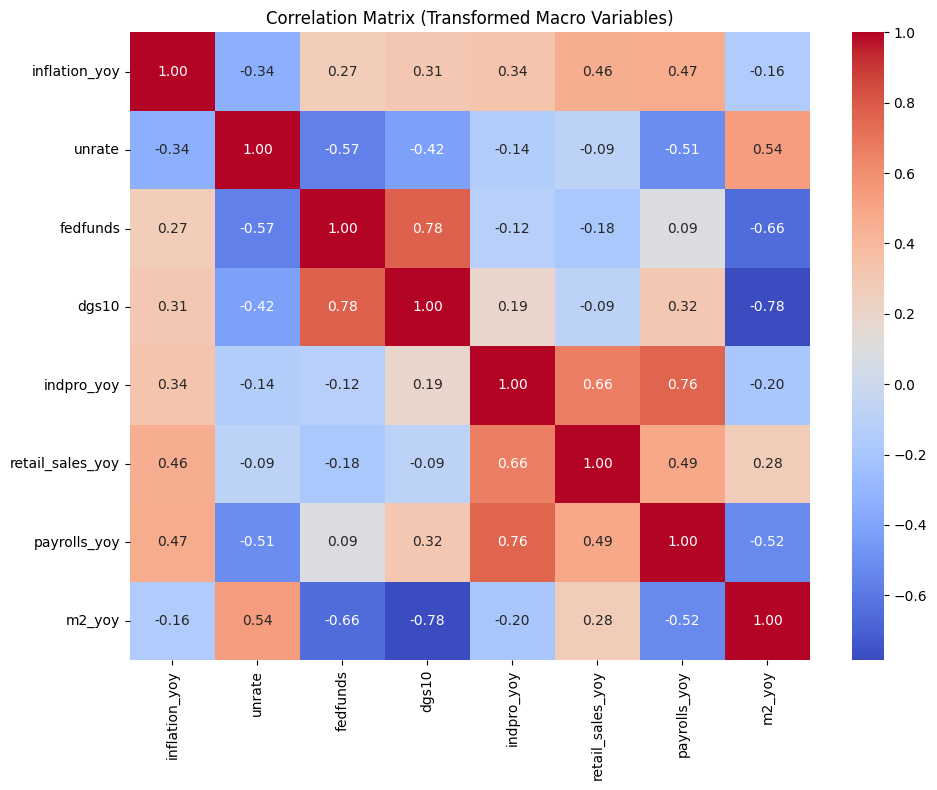

In [8]:
df_t = df.copy()

for col in ["cpi", "payrolls", "retail_sales", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = df_t[col].pct_change(12) * 100

df_t["inflation_yoy"] = df_t["cpi_yoy"]

use_cols = [
    "inflation_yoy", "unrate", "fedfunds", "dgs10",
    "indpro_yoy", "retail_sales_yoy", "payrolls_yoy", "m2_yoy"
]

df_t = df_t[use_cols].dropna()   # select columns + drop NA

plt.figure(figsize=(10, 8))
sns.heatmap(df_t.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix (Transformed Macro Variables)")
plt.tight_layout()
plt.show()

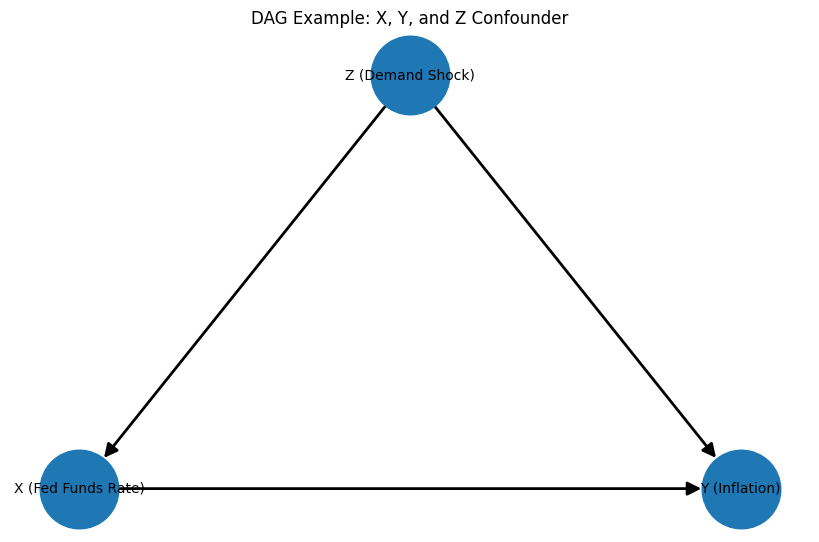

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# X = policy rate, Y = inflation, Z = confounder
G.add_edges_from([
    ("Z (Demand Shock)", "X (Fed Funds Rate)"),
    ("Z (Demand Shock)", "Y (Inflation)"),
    ("X (Fed Funds Rate)", "Y (Inflation)")  # optional direct causal path
])

pos = {
    "Z (Demand Shock)": (0, 1),
    "X (Fed Funds Rate)": (-1, 0),
    "Y (Inflation)": (1, 0)
}

plt.figure(figsize=(8, 5))
nx.draw(
    G, pos, with_labels=True,
    node_size=3200, font_size=10,
    arrows=True, arrowstyle='-|>', arrowsize=20,
    width=2
)
plt.title("DAG Example: X, Y, and Z Confounder")
plt.axis("off")
plt.show()

In [11]:
"""
=============================================================================
ECONOMETRICS LAB EXPANSION — INFLATION DYNAMICS CO-PILOT
=============================================================================
Purpose : Expand a manual FRED-based inflation regression with new variables,
          robustness checks, interactive visualization, and causal caveats.
Author  : [Your Name]
Date    : 2026-02-27
=============================================================================
"""

# ── 0. IMPORTS ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# FRED data access
from fredapi import Fred

# Regression & diagnostics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Interactive plotting
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── 1. FRED API SETUP ──────────────────────────────────────────────────────
# Replace with your free FRED API key from https://fred.stlouisfed.org/docs/api/api_key.html
FRED_API_KEY = "YOUR_FRED_API_KEY_HERE"
fred = Fred(api_key=FRED_API_KEY)

# ── 2. DATA PULL — ORIGINAL + 3 NEW VARIABLES ──────────────────────────────
#
# YOUR ORIGINAL VARIABLES (from the manual lab):
#   CPIAUCSL  — CPI-U, All Items (proxy for inflation level)
#   UNRATE    — Civilian Unemployment Rate
#   FEDFUNDS  — Effective Federal Funds Rate
#
# ┌──────────────────────────────────────────────────────────────────────────┐
# │  3 NEW VARIABLES & WHY THEY MATTER                                      │
# │                                                                          │
# │  1. MICH  — University of Michigan Inflation Expectations (1-Year)       │
# │     WHY:  Expectations are central to New Keynesian Phillips Curve       │
# │           models. If households *expect* higher inflation, they          │
# │           negotiate higher wages and accept higher prices, creating      │
# │           a self-fulfilling loop. Omitting expectations biases the       │
# │           unemployment coefficient toward zero (omitted variable bias).  │
# │                                                                          │
# │  2. PPIACO — Producer Price Index, All Commodities                       │
# │     WHY:  PPI captures upstream cost-push pressures (energy, raw        │
# │           materials) before they pass through to consumer prices.        │
# │           Including PPI helps distinguish demand-pull from cost-push     │
# │           inflation — a distinction OLS on CPI alone cannot make.        │
# │                                                                          │
# │  3. M2SL  — M2 Money Supply                                              │
# │     WHY:  Monetarist channel: MV = PQ implies excess money growth       │
# │           (beyond real output growth) should predict inflation.          │
# │           Post-2020 M2 surged ~40%; including it lets us test whether    │
# │           money growth has independent explanatory power after           │
# │           controlling for expectations and slack.                        │
# └──────────────────────────────────────────────────────────────────────────┘

# Dictionary mapping FRED series IDs to human-readable names
series = {
    "CPIAUCSL": "cpi",           # Consumer Price Index (level)
    "UNRATE":   "unemployment",  # Unemployment rate (%)
    "FEDFUNDS": "fed_funds",     # Federal funds rate (%)
    "MICH":     "infl_expect",   # Michigan 1-yr inflation expectations (%)
    "PPIACO":   "ppi",           # Producer Price Index (level)
    "M2SL":     "m2",            # M2 money supply (level, billions $)
}

# Pull each series and store in a single DataFrame, aligned on monthly dates
raw_frames = []
for fred_id, col_name in series.items():
    s = fred.get_series(fred_id, observation_start="1980-01-01")
    s.name = col_name
    raw_frames.append(s)

# Outer-join keeps all dates; we forward-fill small gaps then drop remaining NaNs
df_raw = pd.concat(raw_frames, axis=1)
df_raw.index = pd.to_datetime(df_raw.index)

# Resample to monthly frequency (some series are already monthly; this standardizes)
df_raw = df_raw.resample("MS").last()   # "MS" = month-start frequency
df_raw = df_raw.ffill(limit=3).dropna() # forward-fill up to 3 months, then drop

print(f"Raw dataset: {df_raw.shape[0]} months × {df_raw.shape[1]} variables")
print(f"Date range : {df_raw.index.min():%Y-%m} to {df_raw.index.max():%Y-%m}\n")


# ── 3. VARIABLE TRANSFORMATIONS ─────────────────────────────────────────────
#
# WHY TRANSFORM?
#   CPI, PPI, and M2 are *level* variables with strong upward trends.
#   Regressing trending variables on each other produces spuriously high R²
#   and biased standard errors — the classic "spurious regression" problem
#   (Granger & Newbold, 1974).
#
#   Solution: convert levels → Year-over-Year (YoY) growth rates.
#   This removes the stochastic trend and gives us economically meaningful
#   percentage changes.
#
#   Variables already in rates (UNRATE, FEDFUNDS, MICH) stay as-is.

df = df_raw.copy()

# YoY % change: (X_t - X_{t-12}) / X_{t-12} * 100
# .pct_change(12) computes the 12-month percentage change automatically
df["cpi_yoy"]  = df["cpi"].pct_change(12)  * 100   # Inflation rate (%)
df["ppi_yoy"]  = df["ppi"].pct_change(12)  * 100   # PPI growth rate (%)
df["m2_yoy"]   = df["m2"].pct_change(12)   * 100   # Money supply growth (%)

# Drop the first 12 rows (no valid YoY calculation) and any remaining NaNs
df = df.dropna()

# Define the dependent variable and regressors clearly
y_var = "cpi_yoy"                                                  # What we're explaining
x_vars_baseline = ["unemployment", "fed_funds", "infl_expect",     # Baseline regressors
                    "ppi_yoy", "m2_yoy"]

print("Transformed variables ready. Sample of growth rates:")
print(df[[y_var] + x_vars_baseline].tail())
print()


# ── 4. BASELINE OLS REGRESSION (EXPANDED) ───────────────────────────────────
#
# MODEL:  cpi_yoy = β₀ + β₁·unemployment + β₂·fed_funds + β₃·infl_expect
#                       + β₄·ppi_yoy + β₅·m2_yoy + ε
#
# INTERPRETATION GUIDE:
#   β₁ < 0  → Phillips Curve: lower unemployment ↔ higher inflation
#   β₂ < 0  → Tighter monetary policy reduces inflation (with lag — see below)
#   β₃ > 0  → Expectations channel: higher expected inflation → higher actual
#   β₄ > 0  → Cost-push: upstream price rises pass through to CPI
#   β₅ > 0  → Monetarist channel: excess money growth fuels inflation

X_base = sm.add_constant(df[x_vars_baseline])  # Add intercept column
y = df[y_var]

model_baseline = sm.OLS(y, X_base).fit(cov_type="HC1")
# HC1 = heteroskedasticity-consistent (White) standard errors
# WHY: OLS assumes constant variance of residuals. Macro data almost never
#       satisfies this. HC1 gives robust SEs without assuming homoskedasticity.

print("=" * 72)
print("BASELINE OLS — EXPANDED INFLATION MODEL")
print("=" * 72)
print(model_baseline.summary())
print()


# ── 5. MULTICOLLINEARITY DIAGNOSTIC — VIF ──────────────────────────────────
#
# Variance Inflation Factor: VIF_j = 1 / (1 - R²_j)
#   where R²_j is from regressing X_j on all other X's.
#
# RULE OF THUMB:
#   VIF < 5  → acceptable
#   VIF 5-10 → concerning, check pairwise correlations
#   VIF > 10 → serious multicollinearity, consider dropping or combining

print("VARIANCE INFLATION FACTORS (baseline model):")
print("-" * 45)
for i, col in enumerate(X_base.columns):
    if col == "const":
        continue  # VIF for the intercept is meaningless
    vif_value = variance_inflation_factor(X_base.values, i)
    flag = " ⚠️  HIGH" if vif_value > 5 else ""
    print(f"  {col:20s}  VIF = {vif_value:6.2f}{flag}")
print()


# =============================================================================
# ── 6. ROBUSTNESS CHECK #1 — LAGGED REGRESSORS ─────────────────────────────
# =============================================================================
#
# WHY LAGS?
#   Monetary policy doesn't affect inflation instantly. Milton Friedman's
#   "long and variable lags" suggests 12-18 months for fed funds → CPI.
#   Similarly, money supply growth takes time to transmit through the economy.
#
#   By using X_{t-12} to predict Y_t, we:
#     (a) Respect the temporal ordering (cause precedes effect)
#     (b) Reduce simultaneity bias (current inflation can't cause *last year's*
#         fed funds rate)
#     (c) Align with how policymakers actually forecast
#
# RISK: Choosing the "right" lag is subjective. Different lags can flip signs
#        or significance. Report multiple lags to show sensitivity.

lag_months = 12  # 12-month lag (1 year)

# Shift regressors backward in time: row t gets the regressor value from t-12
df_lagged = df.copy()
for var in x_vars_baseline:
    df_lagged[f"{var}_L{lag_months}"] = df_lagged[var].shift(lag_months)

df_lagged = df_lagged.dropna()

# Build lagged regressor list
x_vars_lagged = [f"{v}_L{lag_months}" for v in x_vars_baseline]

X_lag = sm.add_constant(df_lagged[x_vars_lagged])
y_lag = df_lagged[y_var]

model_lagged = sm.OLS(y_lag, X_lag).fit(cov_type="HC1")

print("=" * 72)
print(f"ROBUSTNESS CHECK #1 — {lag_months}-MONTH LAGGED REGRESSORS")
print("=" * 72)
print(model_lagged.summary())
print()

# ⚠️ ASSUMPTION FLAG:
# "The 12-month lag is a modeling choice, not a known structural parameter.
#  Try 6, 12, 18, and 24 months; if the sign of β flips or significance
#  vanishes, the result is fragile and you should say so."


# =============================================================================
# ── 7. ROBUSTNESS CHECK #2 — SUBSAMPLE EXCLUDING CRISIS PERIODS ────────────
# =============================================================================
#
# WHY EXCLUDE CRISES?
#   Structural breaks (Volcker disinflation 1980-82, Great Recession 2008-09,
#   COVID 2020-21) can dominate OLS estimates because they produce extreme
#   outliers in both Y and X.
#
#   If your coefficients change dramatically when you drop these periods, the
#   model is not stable — it's being driven by a few extreme observations.
#   That's important to disclose.
#
# WHAT WE REMOVE:
#   - Volcker shock   : 1980-01 to 1982-12  (intentional severe tightening)
#   - Great Recession : 2007-12 to 2009-06  (financial crisis, ZLB)
#   - COVID pandemic  : 2020-03 to 2021-12  (supply shock + massive stimulus)

crisis_mask = (
    # Volcker disinflation
    ((df.index >= "1980-01-01") & (df.index <= "1982-12-01")) |
    # Great Recession
    ((df.index >= "2007-12-01") & (df.index <= "2009-06-01")) |
    # COVID pandemic
    ((df.index >= "2020-03-01") & (df.index <= "2021-12-01"))
)

df_no_crisis = df[~crisis_mask]  # Keep only non-crisis months

n_dropped = crisis_mask.sum()
n_remaining = len(df_no_crisis)
print(f"Dropped {n_dropped} crisis months → {n_remaining} observations remain.\n")

X_nc = sm.add_constant(df_no_crisis[x_vars_baseline])
y_nc = df_no_crisis[y_var]

model_no_crisis = sm.OLS(y_nc, X_nc).fit(cov_type="HC1")

print("=" * 72)
print("ROBUSTNESS CHECK #2 — EXCLUDING CRISIS PERIODS")
print("=" * 72)
print(model_no_crisis.summary())
print()


# =============================================================================
# ── 8. COEFFICIENT COMPARISON TABLE ─────────────────────────────────────────
# =============================================================================
#
# Side-by-side view: how do coefficients change across specifications?
# Large swings → fragile result. Stable signs → more confidence.

def extract_coefs(model, label):
    """Pull coefficients and p-values into a tidy DataFrame."""
    return pd.DataFrame({
        f"{label}_coef": model.params,
        f"{label}_pval": model.pvalues,
    })

comparison = pd.concat([
    extract_coefs(model_baseline,   "Baseline"),
    extract_coefs(model_lagged,     "Lagged_12m"),
    extract_coefs(model_no_crisis,  "NoCrisis"),
], axis=1).round(4)

print("=" * 72)
print("COEFFICIENT COMPARISON ACROSS SPECIFICATIONS")
print("=" * 72)
print(comparison.to_string())
print()
print("KEY: Look for sign flips or large magnitude changes across columns.")
print("     Stable coefficients = more trustworthy inference.\n")


# =============================================================================
# ── 9. INTERACTIVE PLOTLY CHART — INFLATION, UNEMPLOYMENT, FED FUNDS ────────
# =============================================================================
#
# WHY INTERACTIVE?
#   Static plots can't zoom into specific episodes. Plotly lets you hover
#   over the Volcker shock, the 2008 crisis, or the 2021 inflation surge
#   and see exact values — useful for class discussion.

fig = make_subplots(
    rows=3, cols=1,
    shared_xaxes=True,           # All three panels share the same time axis
    vertical_spacing=0.06,       # Tight spacing between panels
    subplot_titles=(
        "CPI Inflation (YoY %)",
        "Unemployment Rate (%)",
        "Effective Federal Funds Rate (%)"
    ),
)

# ── Panel 1: Inflation ──
fig.add_trace(
    go.Scatter(
        x=df.index, y=df["cpi_yoy"],
        name="CPI YoY",
        line=dict(color="#E63946", width=2),         # Red — convention for inflation
        hovertemplate="%{x|%Y-%m}<br>Inflation: %{y:.1f}%<extra></extra>",
    ),
    row=1, col=1,
)
# Add a reference line at the Fed's 2% target
fig.add_hline(y=2, line_dash="dash", line_color="gray",
              annotation_text="2% target", row=1, col=1)

# ── Panel 2: Unemployment ──
fig.add_trace(
    go.Scatter(
        x=df.index, y=df["unemployment"],
        name="Unemployment",
        line=dict(color="#457B9D", width=2),          # Blue — convention for labor
        hovertemplate="%{x|%Y-%m}<br>Unemp: %{y:.1f}%<extra></extra>",
    ),
    row=2, col=1,
)

# ── Panel 3: Fed Funds ──
fig.add_trace(
    go.Scatter(
        x=df.index, y=df["fed_funds"],
        name="Fed Funds",
        line=dict(color="#2A9D8F", width=2),          # Teal — monetary policy
        hovertemplate="%{x|%Y-%m}<br>FFR: %{y:.2f}%<extra></extra>",
    ),
    row=3, col=1,
)

# ── Shade crisis periods across all panels ──
crisis_periods = [
    ("1980-01-01", "1982-12-01", "Volcker"),
    ("2007-12-01", "2009-06-01", "Great Recession"),
    ("2020-03-01", "2021-12-01", "COVID"),
]
for start, end, label in crisis_periods:
    for row in [1, 2, 3]:
        fig.add_vrect(
            x0=start, x1=end,
            fillcolor="rgba(200,200,200,0.25)",       # Light gray shading
            line_width=0,
            annotation_text=label if row == 1 else "", # Label only on top panel
            annotation_position="top left",
            row=row, col=1,
        )

# ── Layout polish ──
fig.update_layout(
    height=800,
    title_text="Inflation Dynamics Dashboard — FRED Data (1981–Present)",
    title_font_size=18,
    showlegend=False,             # Labels are in subplot titles
    template="plotly_white",      # Clean academic style
    hovermode="x unified",       # Hover syncs across panels
)

# Save as an interactive HTML file you can open in any browser
fig.write_html("inflation_dashboard.html", include_plotlyjs="cdn")
print("✅ Interactive chart saved → inflation_dashboard.html")
print("   Open in a browser to zoom, hover, and explore.\n")

# Optionally display inline (works in Jupyter)
# fig.show()


# =============================================================================
# ── 10. ASSUMPTIONS, CAVEATS & SPURIOUS INFERENCE RISKS ─────────────────────
# =============================================================================

caveats = """
╔══════════════════════════════════════════════════════════════════════════╗
║                  ASSUMPTIONS & SPURIOUS INFERENCE RISKS                  ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  1. STATIONARITY                                                         ║
║     YoY growth rates reduce trending behavior, but they may still be     ║
║     non-stationary during structural breaks. Formally test with ADF      ║
║     (Augmented Dickey-Fuller) before trusting t-statistics.              ║
║     → Run: from statsmodels.tsa.stattools import adfuller                ║
║                                                                          ║
║  2. SIMULTANEITY / ENDOGENEITY                                           ║
║     OLS assumes X → Y, but causation runs both ways:                     ║
║       • Inflation → Fed raises rates (reverse causality)                 ║
║       • Unemployment ↔ Inflation (Phillips Curve is simultaneous)        ║
║     OLS cannot disentangle this. You would need IV/2SLS or a             ║
║     structural VAR for causal claims.                                    ║
║                                                                          ║
║  3. OMITTED VARIABLE BIAS                                                ║
║     Even with 5 regressors, we omit: oil shocks, supply chain            ║
║     disruptions, fiscal policy, exchange rates, global demand.           ║
║     Any omitted variable correlated with both X and Y biases all β's.   ║
║                                                                          ║
║  4. LUCAS CRITIQUE                                                       ║
║     Historical correlations can break when policy regimes change.        ║
║     The Volcker era, the ZLB era, and the post-COVID era may each        ║
║     have different data-generating processes. Pooling them into one      ║
║     regression assumes structural stability — a strong assumption.       ║
║                                                                          ║
║  5. AUTOCORRELATED RESIDUALS                                             ║
║     Macro time series almost always have serially correlated errors.     ║
║     HC1 fixes heteroskedasticity but NOT autocorrelation.                ║
║     → Use Newey-West (HAC) standard errors for better inference:         ║
║       model.fit(cov_type="HAC", cov_kwds={"maxlags": 12})               ║
║                                                                          ║
║  6. DATA-SNOOPING / OVERFITTING                                         ║
║     Every additional variable or lag we try inflates the risk of         ║
║     finding "significant" results by chance. With 5 regressors and      ║
║     3 specifications, we're running ~15 implicit hypothesis tests.       ║
║     Apply a Bonferroni correction or hold out a test period.             ║
║                                                                          ║
║  BOTTOM LINE:                                                            ║
║     This is a *descriptive correlation study*, not a causal analysis.    ║
║     Say: "Inflation is associated with X" — never "X causes inflation." ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(caveats)


# =============================================================================
# ── 11. OPTIONAL NEXT STEPS (for extra credit / further exploration) ────────
# =============================================================================
#
# If you want to go further, here are principled extensions:
#
#   A. NEWEY-WEST STANDARD ERRORS
#      model.fit(cov_type="HAC", cov_kwds={"maxlags": 12})
#      Corrects for both heteroskedasticity AND autocorrelation.
#
#   B. AUGMENTED DICKEY-FULLER TEST (stationarity check)
#      from statsmodels.tsa.stattools import adfuller
#      for var in [y_var] + x_vars_baseline:
#          result = adfuller(df[var])
#          print(f"{var}: ADF stat={result[0]:.3f}, p={result[1]:.4f}")
#
#   C. GRANGER CAUSALITY TEST (does X help *predict* Y beyond Y's own lags?)
#      from statsmodels.tsa.stattools import grangercausalitytests
#      grangercausalitytests(df[["cpi_yoy","m2_yoy"]].dropna(), maxlag=12)
#
#   D. ROLLING REGRESSION (check if β is stable over time)
#      from statsmodels.regression.rolling import RollingOLS
#      rolling = RollingOLS(y, X_base, window=60).fit()  # 5-year window
#      rolling.params["unemployment"].plot()  # Plot β₁ over time
#
#   E. STRUCTURAL BREAK TEST (Chow test or Bai-Perron)
#      Formally test whether the crisis periods represent regime changes.

print("Script complete. Review each section before presenting in class.")
print("Remember: you must be able to explain every line. If something is")
print("unclear, that's a signal to dig deeper — which is the whole point.\n")

ModuleNotFoundError: No module named 'fredapi'